# 01 - EDA and Feature Engineering
Standard-classification track. The competition is a survival task: predict, per fire, the probability of threatening an evacuation zone within 12/24/48/72h from `t0+5h`.

**Per-horizon labels.** For horizon H a fire is usable only if its status at H is known: `y=1` if it hit by H; `y=0` if followed past H without a hit; dropped if censored before H. At H=72 the label equals `event` (the full-window indicator).

In [2]:
!pip install -q kaggle numpy pandas scikit-learn matplotlib

import sys
from pathlib import Path

# Download datasets (public, no credentials needed)
!kaggle datasets download -d gpla77/zum-pro-data -p /content/data --unzip
!kaggle datasets download -d gpla77/zum-pro-code  -p /content/src_pkg  --unzip

# Verify data files
DATA = Path("/content/data/data")
REQUIRED = ["train.csv", "test.csv", "sample_submission.csv", "metaData.csv"]
missing = [f for f in REQUIRED if not (DATA / f).exists()]
if missing:
    raise FileNotFoundError(f"Missing data files: {missing}")
print("Data OK:", [f for f in REQUIRED])

# Verify src module
SRC = Path("/content/src_pkg")
src_files = ["utils.py", "data_loader.py", "preprocessing.py", "models.py", "evaluation.py"]
missing_src = [f for f in src_files if not (SRC / "src" / f).exists()]
if missing_src:
    raise FileNotFoundError(f"Missing src files: {missing_src}")
print("Src OK:", src_files)

sys.path.insert(0, str(SRC))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.utils import set_global_seed, HORIZONS, save_figure, save_table
from src import data_loader as dl, preprocessing as pp, models as M, evaluation as ev
set_global_seed()
print("Setup complete, ROOT:", SRC, "| DATA:", DATA)

Dataset URL: https://www.kaggle.com/datasets/gpla77/zum-pro-data
License(s): unknown
100% 27.9k/27.9k [00:00<00:00, 59.3MB/s]

Dataset URL: https://www.kaggle.com/datasets/gpla77/zum-pro-code
License(s): unknown
100% 8.54k/8.54k [00:00<00:00, 22.5MB/s]

Data OK: ['train.csv', 'test.csv', 'sample_submission.csv', 'metaData.csv']
Src OK: ['utils.py', 'data_loader.py', 'preprocessing.py', 'models.py', 'evaluation.py']
Setup complete, ROOT: /content/src_pkg | DATA: /content/data/data


In [3]:
train, test, submission, meta = dl.load_raw(folder=DATA)
features = dl.feature_columns(train)
print('train:', train.shape, '| test:', test.shape, '| features:', len(features))
print('missing train/test:', int(train.isna().sum().sum()), int(test.isna().sum().sum()),
      '| duplicate rows:', int(train.duplicated().sum()))

train: (221, 37) | test: (95, 35) | features: 34
missing train/test: 0 0 | duplicate rows: 0


In [5]:
meta[['column','category','description']].head(40)

,column,category,description
0,event_id,identifier,Anonymized fire event identifier (stable rando...
1,time_to_hit_hours,target,Time from t0+5h until fire comes within 5km of...
2,event,target,"Event indicator: 1 if fire hit within 72h, 0 i..."
3,num_perimeters_0_5h,temporal_coverage,Number of perimeters within first 5 hours
4,dt_first_last_0_5h,temporal_coverage,Time span between first and last perimeter (ho...
5,low_temporal_resolution_0_5h,temporal_coverage,"Flag: 1 if dt < 0.5h or only 1 perimeter, else 0"
6,area_first_ha,growth,Initial fire area at t0 (hectares)
7,area_growth_abs_0_5h,growth,Feature from growth category
8,area_growth_rel_0_5h,growth,Feature from growth category
9,area_growth_rate_ha_per_h,growth,Area growth rate (hectares per hour)


## Target structure

event
censored (0)    152
hit (1)          69


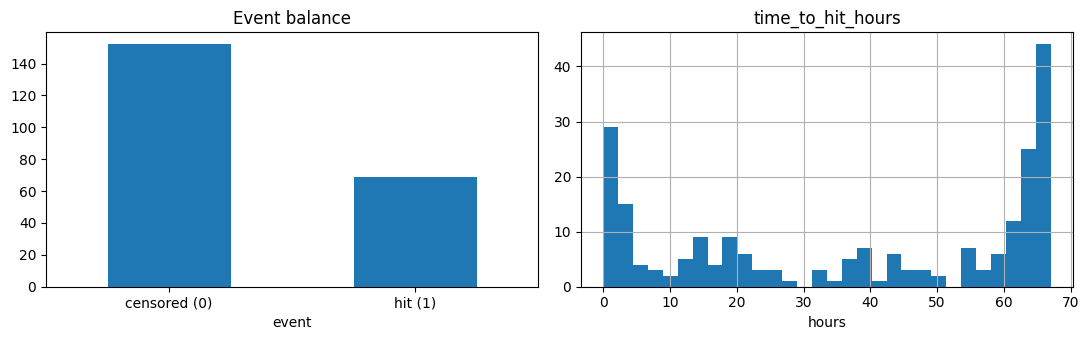

In [6]:
ev_counts = train['event'].value_counts().rename({0:'censored (0)',1:'hit (1)'})
print(ev_counts.to_string())
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ev_counts.plot(kind='bar', ax=ax[0], title='Event balance'); ax[0].tick_params(axis='x', rotation=0)
train['time_to_hit_hours'].hist(bins=30, ax=ax[1]); ax[1].set_title('time_to_hit_hours'); ax[1].set_xlabel('hours')
fig.tight_layout(); save_figure(fig, 'eda_target.png'); plt.show()

## Per-horizon usable counts
The 72h problem has no fire observed to 72h, so its label uses `event` directly; otherwise it would have no negatives.

In [7]:
label_tbl = dl.label_summary(train, HORIZONS)
save_table(label_tbl, 'label_summary.csv')
label_tbl

,horizon_h,positives,negatives,excluded,usable
0,12,49,166,6,215
1,24,63,133,25,196
2,48,66,100,55,166
3,72,69,152,0,221


## Feature groups and a few distributions

category
centroid_kinematics     5
directionality          4
distance                9
growth                 10
identifier              1
temporal_coverage       3
temporal_metadata       3


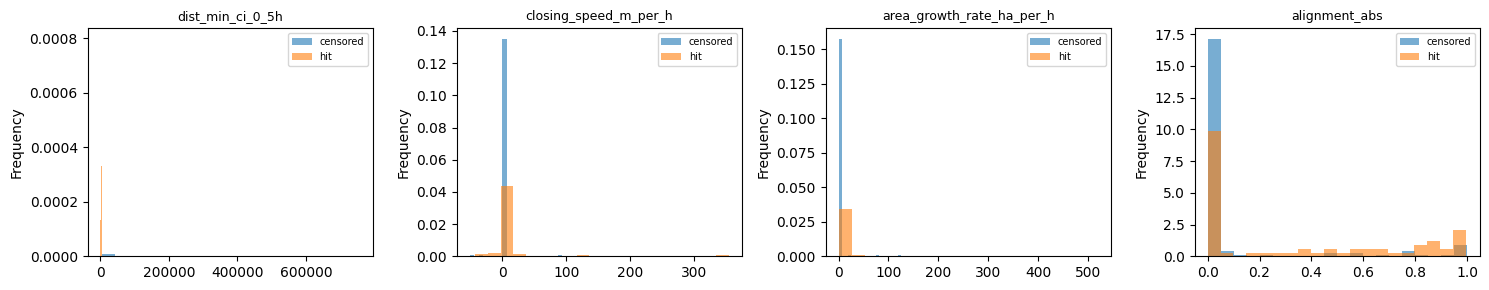

In [8]:
print(meta[meta['category']!='target'].groupby('category')['column'].count().to_string())
key = ['dist_min_ci_0_5h','closing_speed_m_per_h','area_growth_rate_ha_per_h','alignment_abs']
fig, ax = plt.subplots(1, 4, figsize=(15, 3))
for a, c in zip(ax, key):
    for v, lab in [(0,'censored'),(1,'hit')]:
        train.loc[train['event']==v, c].plot(kind='hist', bins=20, alpha=0.6, ax=a, label=lab, density=True)
    a.set_title(c, fontsize=9); a.legend(fontsize=7)
fig.tight_layout(); save_figure(fig, 'eda_feature_dists.png'); plt.show()

Distance to the zone and closing speed separate hit from censored fires, as expected.

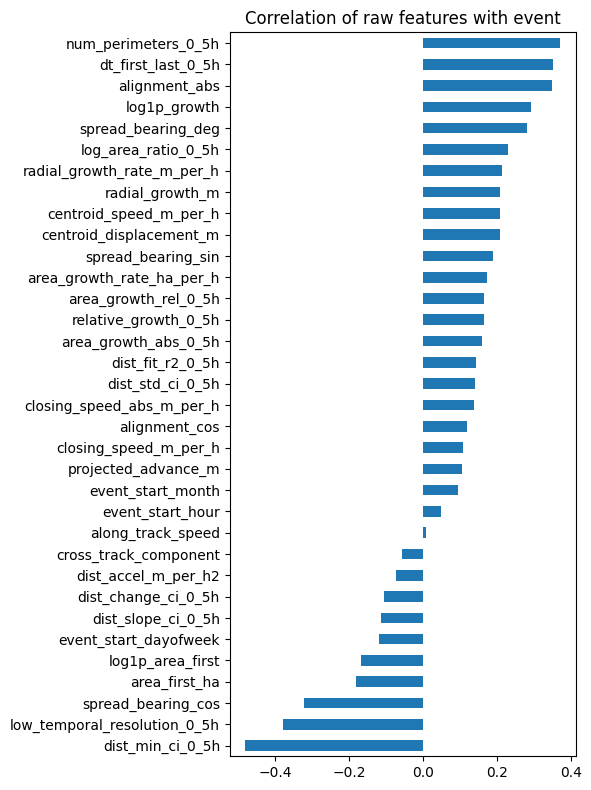

In [9]:
corr = train[features + ['event']].corr()['event'].drop('event').sort_values()
fig, ax = plt.subplots(figsize=(6, 8))
corr.plot(kind='barh', ax=ax); ax.set_title('Correlation of raw features with event')
fig.tight_layout(); save_figure(fig, 'eda_corr_event.png'); plt.show()

## Feature engineering
Cyclic sin/cos encoding for hour/day-of-week/month, the redundant raw bearing degrees dropped (sin/cos already provided), plus interaction features tied to the physical question of reaching the 5km radius (approach urgency, estimated hours to zone, closing speed aligned to the zone, growth x closing, advance ratio).

In [10]:
eng = pp.engineer_features(train[features])
new_cols = [c for c in eng.columns if c not in features]
print('raw features:', len(features), '-> engineered:', eng.shape[1])
print('added:', new_cols)
print('NaNs after FE:', int(eng.isna().sum().sum()))
eng[new_cols].describe().T.round(3)

raw features: 34 -> engineered: 41
added: ['event_start_hour_sin', 'event_start_hour_cos', 'event_start_dayofweek_sin', 'event_start_dayofweek_cos', 'event_start_month_sin', 'event_start_month_cos', 'approach_urgency', 'est_hours_to_zone', 'closing_x_alignment', 'growth_x_closing', 'advance_ratio']
NaNs after FE: 0


,count,mean,std,min,25%,50%,75%,max
event_start_hour_sin,221.0,-0.405,0.585,-1.000,-0.866,-0.707,0.000,1.000
event_start_hour_cos,221.0,0.460,0.534,-1.000,0.000,0.707,0.866,1.000
event_start_dayofweek_sin,221.0,0.088,0.712,-0.975,-0.782,0.434,0.782,0.975
event_start_dayofweek_cos,221.0,0.020,0.700,-0.901,-0.901,-0.223,0.623,1.000
event_start_month_sin,221.0,-0.367,0.591,-1.000,-0.866,-0.500,0.000,1.000
event_start_month_cos,221.0,-0.636,0.337,-1.000,-0.866,-0.866,-0.500,0.866
approach_urgency,221.0,0.001,0.010,-0.024,0.000,0.000,0.000,0.127
est_hours_to_zone,221.0,9652.248,1803.268,0.000,10000.000,10000.000,10000.000,10000.000
closing_x_alignment,221.0,2.011,23.998,-30.989,0.000,0.000,0.000,319.639
growth_x_closing,221.0,960.380,12422.427,0.000,0.000,0.000,0.000,184299.754


All preprocessing lives in `src/preprocessing.build_preprocessor`, used inside the model pipelines in notebook 02 so scaling is fit per CV fold.